First 5 rows:


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Fruit Category,Fruit Name,Fruit Weight,Fruit Width,Fruit Length,Fruit Colour Score
0,1,Apple,192,8.4,7.3,0.55
1,1,Apple,180,8.0,6.8,0.59
2,1,Apple,176,7.4,7.2,0.60
3,1,Apple,178,7.1,7.8,0.92
4,1,Apple,172,7.4,7.0,0.89



Columns in dataset:
['Fruit Category', 'Fruit Name', 'Fruit Weight', 'Fruit Width', 'Fruit Length', 'Fruit Colour Score']

Using text column: Fruit Name

Cleaned text sample:


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_11139/1361929066.py:48: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include='object').columns.tolist()


,Fruit Name,cleaned_text
0,Apple,apple
1,Apple,apple
2,Apple,apple
3,Apple,apple
4,Apple,apple


/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (5). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (6). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (7). Possibl

TF-IDF matrix shape: (59, 3)


/Users/adnanaltimeemy/miniconda3/envs/coding/lib/python3.12/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (9). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


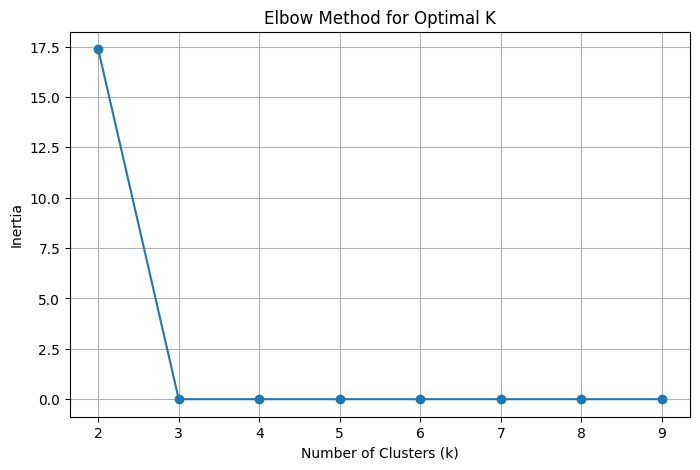


Cluster counts:
cluster
0    24
2    19
1    16
Name: count, dtype: int64

Silhouette Score: 1.0000

Top keywords per cluster:
Cluster 0: orange, lemon, apple
Cluster 1: lemon, orange, apple
Cluster 2: apple, orange, lemon


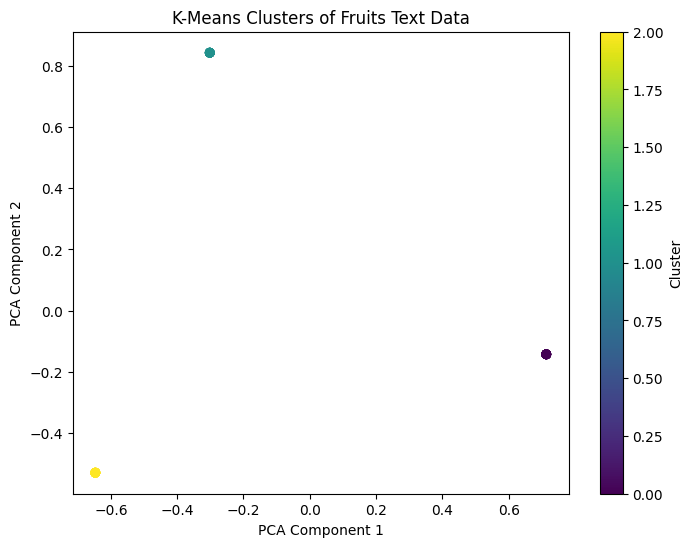

,Fruit Name,cleaned_text,cluster
0,Apple,apple,2
1,Apple,apple,2
2,Apple,apple,2
3,Apple,apple,2
4,Apple,apple,2
5,Apple,apple,2
6,Apple,apple,2
7,Apple,apple,2
8,Apple,apple,2
9,Apple,apple,2



Clustered results saved as Fruits_clustered.csv


In [1]:
# ============================================
# K-MEANS CLUSTERING + NLP FOR Fruits.csv
# ============================================

# Install if needed:
# !pip install pandas numpy matplotlib scikit-learn nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Download NLTK resources (run once)
nltk.download('stopwords')
from nltk.corpus import stopwords

# ============================================
# 1. LOAD DATASET
# ============================================
df = pd.read_csv("Fruits.csv")

print("First 5 rows:")
display(df.head())

print("\nColumns in dataset:")
print(df.columns.tolist())

# ============================================
# 2. SELECT TEXT COLUMN
# ============================================
# Change this if you already know the text column name
possible_text_cols = ['description', 'text', 'fruit_text', 'name', 'fruit_name']

text_col = None
for col in possible_text_cols:
    if col in df.columns:
        text_col = col
        break

if text_col is None:
    # fallback: choose first object/string column
    object_cols = df.select_dtypes(include='object').columns.tolist()
    if len(object_cols) > 0:
        text_col = object_cols[0]
    else:
        raise ValueError("No text column found in Fruits.csv.")

print(f"\nUsing text column: {text_col}")

# Drop missing values
df = df[[text_col]].dropna().copy()

# ============================================
# 3. TEXT PREPROCESSING
# ============================================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()                    # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)    # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()   # remove extra spaces
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_text'] = df[text_col].apply(clean_text)

print("\nCleaned text sample:")
display(df.head())

# ============================================
# 4. CONVERT TEXT TO NUMERICAL FEATURES
# ============================================
vectorizer = TfidfVectorizer(max_features=1000)
X = vectorizer.fit_transform(df['cleaned_text'])

print("TF-IDF matrix shape:", X.shape)

# ============================================
# 5. FIND BEST K USING ELBOW METHOD
# ============================================
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(K_range), inertia, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# ============================================
# 6. TRAIN FINAL K-MEANS MODEL
# ============================================
# Change this after checking elbow plot
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

print("\nCluster counts:")
print(df['cluster'].value_counts())

# ============================================
# 7. EVALUATE USING SILHOUETTE SCORE
# ============================================
if best_k > 1 and X.shape[0] > best_k:
    score = silhouette_score(X, df['cluster'])
    print(f"\nSilhouette Score: {score:.4f}")

# ============================================
# 8. TOP KEYWORDS PER CLUSTER
# ============================================
terms = vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

print("\nTop keywords per cluster:")
for i in range(best_k):
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_words)}")

# ============================================
# 9. VISUALIZE CLUSTERS WITH PCA
# ============================================
pca = PCA(n_components=2)
X_dense = X.toarray()
X_pca = pca.fit_transform(X_dense)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis')
plt.title("K-Means Clusters of Fruits Text Data")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(scatter, label="Cluster")
plt.show()

# ============================================
# 10. SHOW RESULTS
# ============================================
result = df[[text_col, 'cleaned_text', 'cluster']]
display(result.head(20))

# Save clustered results
result.to_csv("Fruits_clustered.csv", index=False)
print("\nClustered results saved as Fruits_clustered.csv")